1. Import Libraries

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (mean_squared_error, accuracy_score, f1_score,
                             precision_score, recall_score, confusion_matrix,
                             classification_report, roc_curve, auc)
# For CNN (optional)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten

%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Data Preprocessing

2.1 Data Loading

In [2]:
# Load the dataset
df = pd.read_csv('telco_churn.csv')
print("✓ Dataset loaded successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"Number of records: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

✓ Dataset loaded successfully!

Dataset shape: (7395, 21)
Number of records: 7395
Number of features: 21


In [3]:
# Display all column names
print("Dataset Columns:")
print(df.columns.tolist())

Dataset Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [4]:
# Display first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Display last few rows
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7390,5275-SQEIZ,Male,0,No,No,1.0,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Mailed check,80.85,NaN,Yes
7391,3282-ZISZV,Male,0,No,Yes,32.0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Credit card (automatic),83.70,2633.3,No
7392,7890-VYYWG,Male,1,Yes,No,3.0,No,No phone service,DSL,No,...,No,No,Yes,No,Month-to-month,Yes,Mailed check,NaN,93.7,Yes
7393,4061-UKJWL,Male,0,No,No,3.0,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Mailed check,45.45,141.7,No
7394,5063-IUOKK,Male,0,No,No,13.0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,NaN,265.75,No


In [6]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7395 entries, 0 to 7394
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7395 non-null   object 
 1   gender            7395 non-null   object 
 2   SeniorCitizen     7395 non-null   int64  
 3   Partner           7395 non-null   object 
 4   Dependents        7395 non-null   object 
 5   tenure            7322 non-null   float64
 6   PhoneService      7395 non-null   object 
 7   MultipleLines     7395 non-null   object 
 8   InternetService   7395 non-null   object 
 9   OnlineSecurity    7395 non-null   object 
 10  OnlineBackup      7395 non-null   object 
 11  DeviceProtection  7395 non-null   object 
 12  TechSupport       7395 non-null   object 
 13  StreamingTV       7395 non-null   object 
 14  StreamingMovies   7395 non-null   object 
 15  Contract          7324 non-null   object 
 16  PaperlessBilling  7395 non-null   object 


In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Check again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7395 entries, 0 to 7394
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7395 non-null   object 
 1   gender            7395 non-null   object 
 2   SeniorCitizen     7395 non-null   int64  
 3   Partner           7395 non-null   object 
 4   Dependents        7395 non-null   object 
 5   tenure            7322 non-null   float64
 6   PhoneService      7395 non-null   object 
 7   MultipleLines     7395 non-null   object 
 8   InternetService   7395 non-null   object 
 9   OnlineSecurity    7395 non-null   object 
 10  OnlineBackup      7395 non-null   object 
 11  DeviceProtection  7395 non-null   object 
 12  TechSupport       7395 non-null   object 
 13  StreamingTV       7395 non-null   object 
 14  StreamingMovies   7395 non-null   object 
 15  Contract          7324 non-null   object 
 16  PaperlessBilling  7395 non-null   object 


In [8]:
# Statistical summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7395.000000,7322.000000,7311.000000,7304.000000
mean,0.161325,32.508741,64.784961,2294.600767
std,0.367856,24.593340,30.121344,2273.873998
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.787500
50%,0.000000,29.000000,70.400000,1410.250000
75%,0.000000,56.000000,89.875000,3822.887500
max,1.000000,72.000000,118.750000,8684.800000


3. Data Preprocessing - Missing Values & Duplicates

3.1 Check Missing Values

In [9]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("Missing Values Summary:")
print(missing_df)
print(f"\nTotal missing values: {missing_values.sum()}")

Missing Values Summary:
                Missing_Count  Missing_Percentage
TotalCharges               91            1.230561
MonthlyCharges             84            1.135903
tenure                     73            0.987153
Contract                   71            0.960108

Total missing values: 319


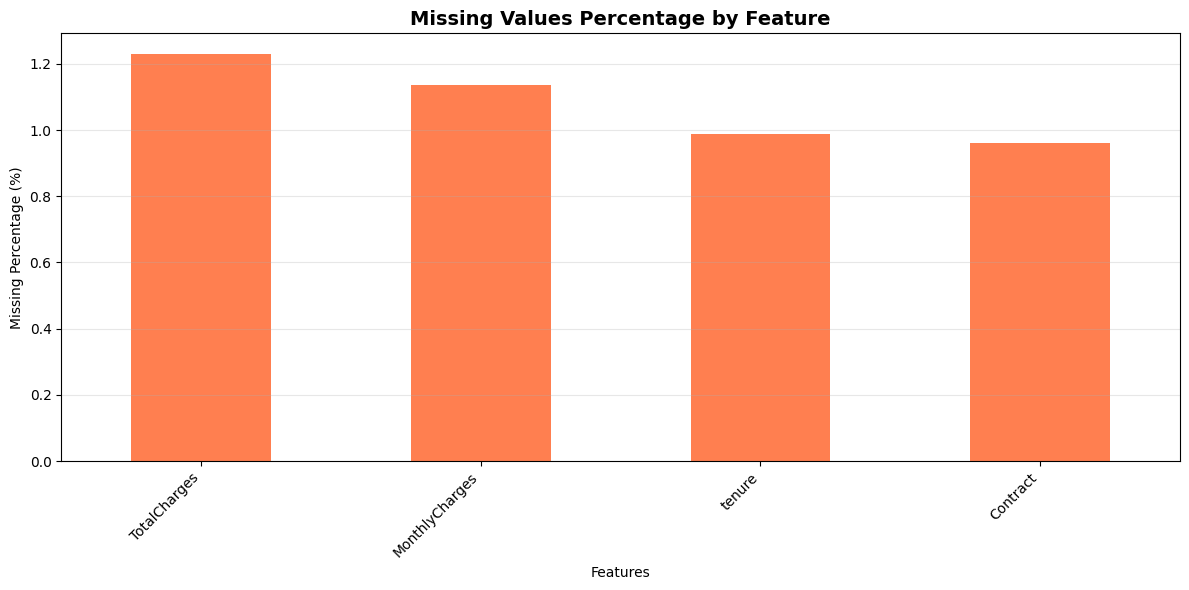

In [10]:
# Visualize missing values
plt.figure(figsize=(12, 6))
missing_df['Missing_Percentage'].plot(kind='bar', color='coral')
plt.title('Missing Values Percentage by Feature', fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Missing Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

3.2 Check for Duplicates

In [11]:
# Check for duplicate records
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print(f"\nPercentage of duplicates: {(duplicates/len(df))*100:.2f}%")
else:
    print("✓ No duplicate records found!")

Number of duplicate rows: 131

Percentage of duplicates: 1.77%


3.3 Handle Missing Values

Strategy:

Numerical features: Use median imputation (robust to outliers)


Categorical features: Use mode imputation


Keep track of which columns had missing values for documentation



In [12]:
# Create a copy for preprocessing
df_clean = df.copy()

# Identify numerical and categorical columns
numerical_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

Numerical columns: 4
Categorical columns: 17


In [13]:
# Handle missing values in numerical columns - use median
for col in numerical_cols:
    if df_clean[col].isnull().sum() > 0:
        median_value = df_clean[col].median()
        df_clean[col].fillna(median_value, inplace=True)
        print(f"✓ Filled {col} with median: {median_value:.2f}")

# Handle missing values in categorical columns - use mode
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_value = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_value, inplace=True)
        print(f"✓ Filled {col} with mode: {mode_value}")

print("\n" + "="*50)
print("Missing values after imputation:")
print(df_clean.isnull().sum().sum())

✓ Filled tenure with median: 29.00
✓ Filled MonthlyCharges with median: 70.40
✓ Filled TotalCharges with median: 1410.25
✓ Filled Contract with mode: Month-to-month

Missing values after imputation:
0


In [14]:
# Verify no missing values remain
print("✓ Data Preprocessing Complete!")
print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

✓ Data Preprocessing Complete!
Original dataset shape: (7395, 21)
Cleaned dataset shape: (7395, 21)
Missing values remaining: 0


3.4 Removing Duplicates

In [15]:
df_clean = df_clean.drop_duplicates()

# Verify again
duplicates = df.duplicated().sum()
duplicates_clean = df_clean.duplicated().sum()
print(f"before duplicate drop: {duplicates}" )
print(f"after duplicate drop : {duplicates_clean}" )
df=df_clean.copy()

before duplicate drop: 131
after duplicate drop : 0


4. Data Transformation

4.1 Drop unnecessary column

In [16]:
df.drop('customerID', axis=1, inplace=True)

4.2 Encoding Binary Variables

In [17]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({
        'Yes': 1, 'No': 0,
        'Female': 1, 'Male': 0
    })

4.3 One-Hot Encoding Categorical Columns

In [18]:
df = pd.get_dummies(df, drop_first=True)

In [19]:
print(df.head())
print("\nData types:\n", df.dtypes)

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       1              0        1           0     1.0             0   
1       0              0        0           0    34.0             1   
2       0              0        0           0     2.0             1   
3       0              0        0           0    45.0             0   
4       1              0        0           0     2.0             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                 1           29.85         29.85      0  ...   
1                 0           56.95       1889.50      0  ...   
2                 1           53.85        108.15      1  ...   
3                 0           42.30       1840.75      0  ...   
4                 1           70.70        151.65      1  ...   

   TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  \
0            False                            False            False   
1            False                    

In [20]:
df_encoded = df.copy()

print("Sample of encoded dataset (including target variable):")
df_encoded.head(10)

Sample of encoded dataset (including target variable):


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1.0,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,0,34.0,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,0,2.0,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,0,45.0,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,1,0,0,0,2.0,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False
5,1,0,0,0,8.0,1,1,99.65,820.50,1,...,False,False,True,False,True,False,False,False,True,False
6,0,0,0,1,22.0,1,1,89.10,1949.40,0,...,False,False,True,False,False,False,False,True,False,False
7,1,0,0,0,10.0,0,0,29.75,301.90,0,...,False,False,False,False,False,False,False,False,False,True
8,1,0,1,0,28.0,1,1,104.80,3046.05,1,...,True,False,True,False,True,False,False,False,True,False
9,0,0,0,1,62.0,1,0,56.15,3487.95,0,...,False,False,False,False,False,True,False,False,False,False


4.4 Feature Scaling

Apply StandardScaler to numerical features for normalization.

In [21]:
# Separate features and target
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nChurn Rate: {(y.sum() / len(y) * 100):.2f}%")

Features shape: (7253, 30)
Target shape: (7253,)

Target distribution:
Churn
0    5336
1    1917
Name: count, dtype: int64

Churn Rate: 26.43%


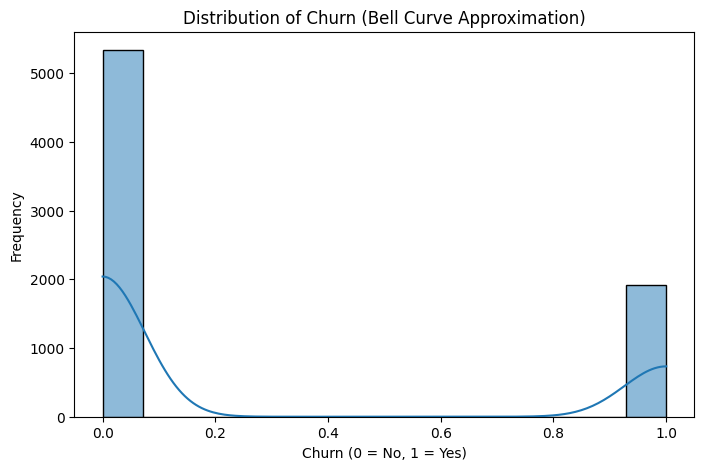

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(y, kde=True)

plt.title("Distribution of Churn (Bell Curve Approximation)")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Frequency")

plt.show()

Here we can see that the data isn't normally distributed. Hence, we need to do the standardization.

In [23]:
# Apply StandardScaler to numerical features
scaler = StandardScaler()

# Create a copy for scaled data
X_scaled = X.copy()

# Scale only numerical columns (excluding already encoded categorical)
numerical_features = [col for col in numerical_cols if col in X.columns]

X_scaled[numerical_features] = scaler.fit_transform(X[numerical_features])

print("✓ Feature scaling complete!")
print(f"\nScaled features shape: {X_scaled.shape}")
print(f"Number of scaled features: {len(numerical_features)}")

✓ Feature scaling complete!

Scaled features shape: (7253, 30)
Number of scaled features: 4


In [24]:
# Compare before and after scaling
print("Before Scaling (first 5 numerical features):")
print(X[numerical_features[:5]].head(3))
print("\n" + "="*70 + "\n")
print("After Scaling (first 5 numerical features):")
print(X_scaled[numerical_features[:5]].head(3))

Before Scaling (first 5 numerical features):
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges
0              0     1.0           29.85         29.85
1              0    34.0           56.95       1889.50
2              0     2.0           53.85        108.15


After Scaling (first 5 numerical features):
   SeniorCitizen    tenure  MonthlyCharges  TotalCharges
0      -0.438789 -1.284126       -1.168555     -0.995376
1      -0.438789  0.064937       -0.263404     -0.172643
2      -0.438789 -1.243245       -0.366945     -0.960735


In [25]:
# Verify transformation complete
print("="*70)
print("✓ DATA TRANSFORMATION COMPLETE!")
print("="*70)
print(f"\nFinal dataset summary:")
print(f"  - Total samples: {len(X_scaled)}")
print(f"  - Total features: {X_scaled.shape[1]}")
print(f"  - Numerical features: {len(numerical_features)}")
print(f"  - Categorical features (encoded): {len(categorical_cols)}")
print(f"  - Target variable: Churn")
print(f"  - Churn rate: {(y.sum() / len(y) * 100):.2f}%")
print(f"\nData is ready for modeling! 🚀")

✓ DATA TRANSFORMATION COMPLETE!

Final dataset summary:
  - Total samples: 7253
  - Total features: 30
  - Numerical features: 4
  - Categorical features (encoded): 17
  - Target variable: Churn
  - Churn rate: 26.43%

Data is ready for modeling! 🚀


5. Exploratory Data Analysis (EDA)

5.1 Target Variable Distribution

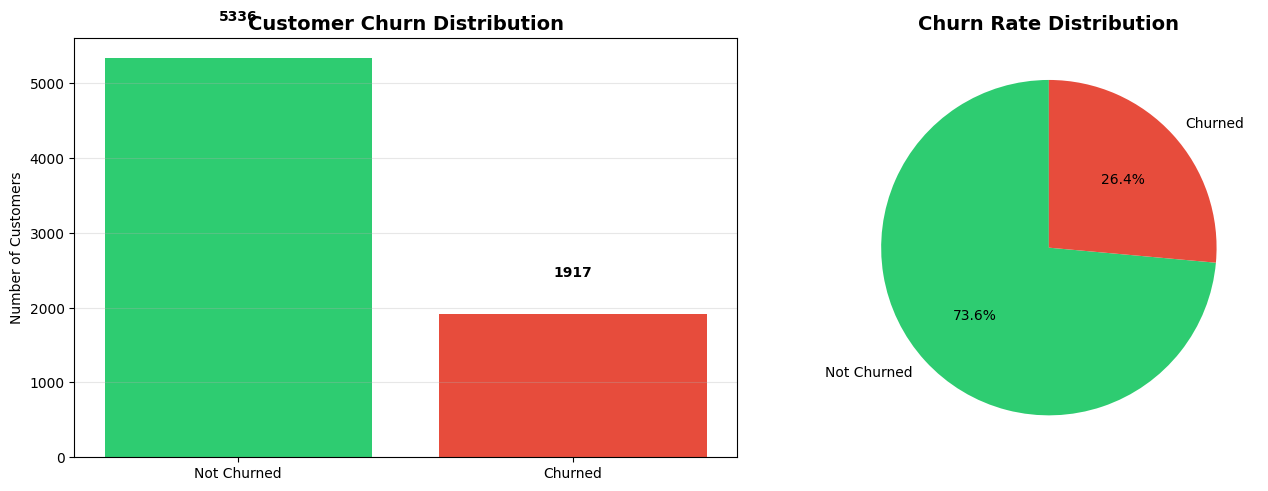

Total Customers: 7253
Not Churned: 5336 (73.57%)
Churned: 1917 (26.43%)


In [26]:
# Visualize churn distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
churn_counts = y.value_counts()
axes[0].bar(['Not Churned', 'Churned'], churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Not Churned', 'Churned'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Churn Rate Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Total Customers: {len(y)}")
print(f"Not Churned: {churn_counts[0]} ({churn_counts[0]/len(y)*100:.2f}%)")
print(f"Churned: {churn_counts[1]} ({churn_counts[1]/len(y)*100:.2f}%)")

5.2 Correlation Analysis

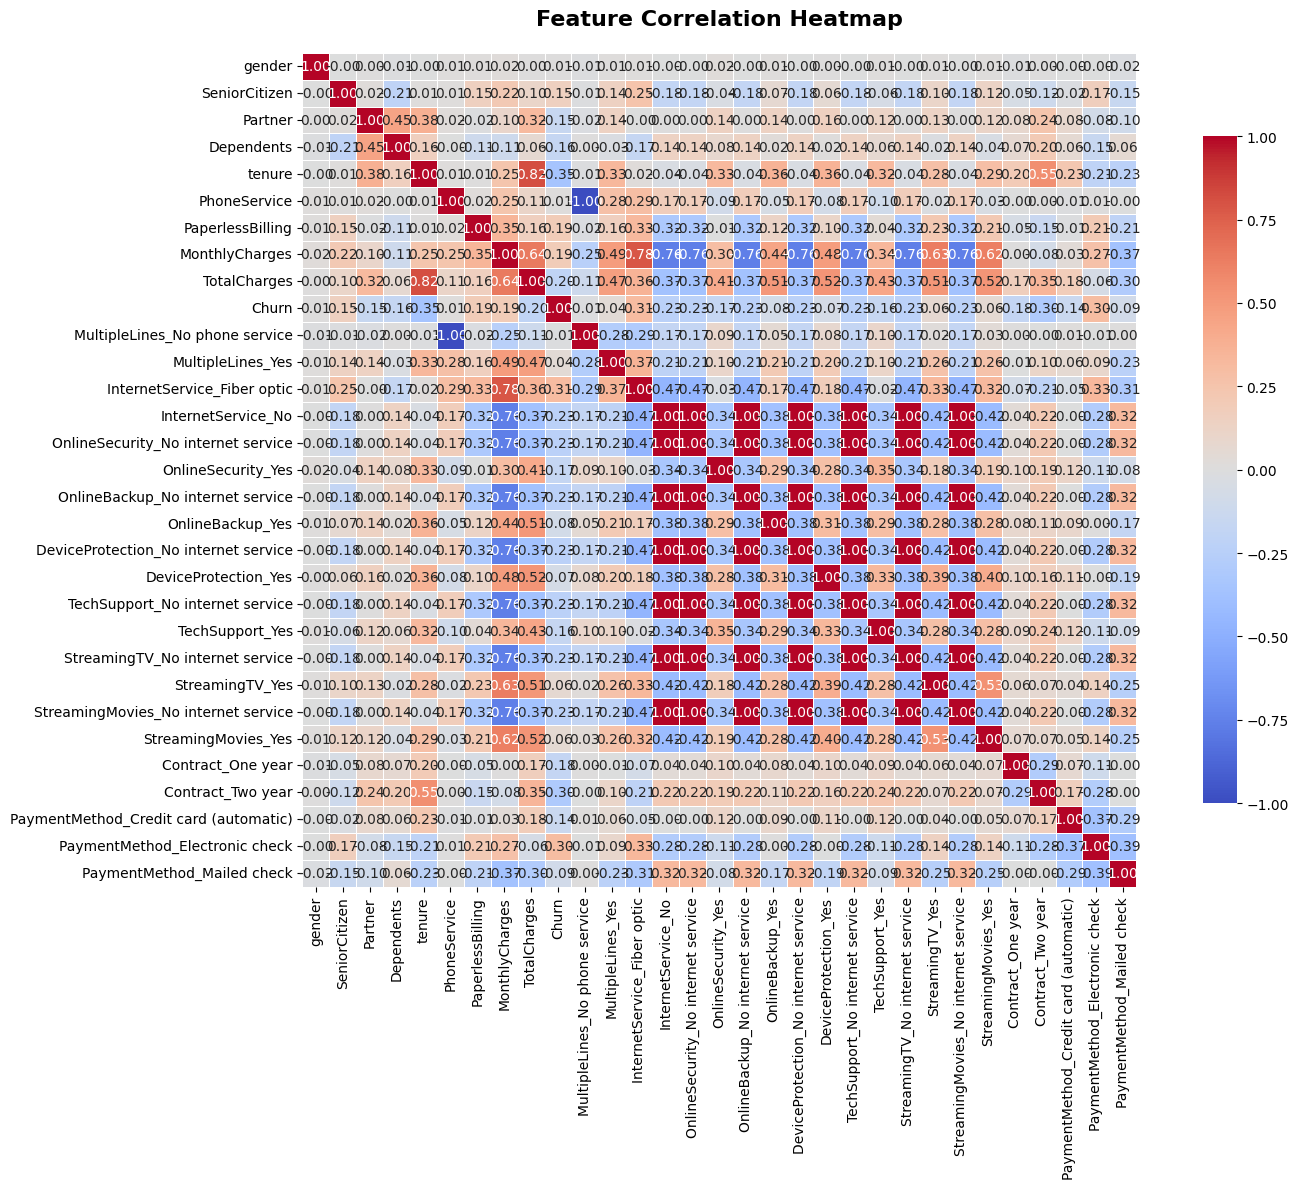

In [27]:
# Calculate correlation matrix
correlation_matrix = df_encoded.corr()

# Create correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Feature Correlation with Churn:
Churn                                    1.000000
InternetService_Fiber optic              0.308121
PaymentMethod_Electronic check           0.302440
MonthlyCharges                           0.192953
PaperlessBilling                         0.191064
SeniorCitizen                            0.149133
StreamingTV_Yes                          0.063709
StreamingMovies_Yes                      0.061651
MultipleLines_Yes                        0.039735
PhoneService                             0.011692
gender                                   0.006770
MultipleLines_No phone service          -0.011692
DeviceProtection_Yes                    -0.067927
OnlineBackup_Yes                        -0.081579
PaymentMethod_Mailed check              -0.090686
PaymentMethod_Credit card (automatic)   -0.135188
Partner                                 -0.150303
TechSupport_Yes                         -0.163676
Dependents                              -0.164834
OnlineSecurity_Yes

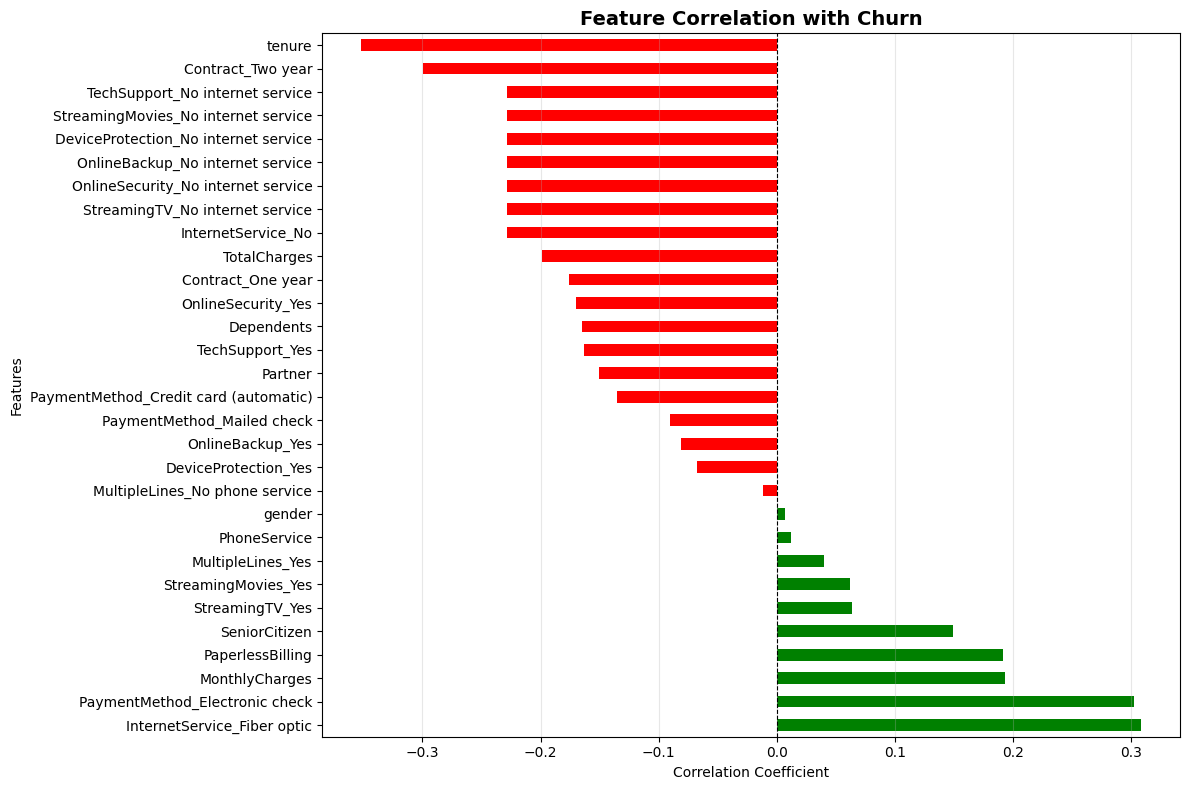

In [28]:
# Feature correlation with target variable
target_correlation = df_encoded.corr()['Churn'].sort_values(ascending=False)

print("Feature Correlation with Churn:")
print("="*50)
print(target_correlation)

# Visualize top correlations
plt.figure(figsize=(12, 8))
target_correlation[1:].plot(kind='barh', color=['green' if x > 0 else 'red' for x in target_correlation[1:]])
plt.title('Feature Correlation with Churn', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

5.3 Numerical Features Distribution

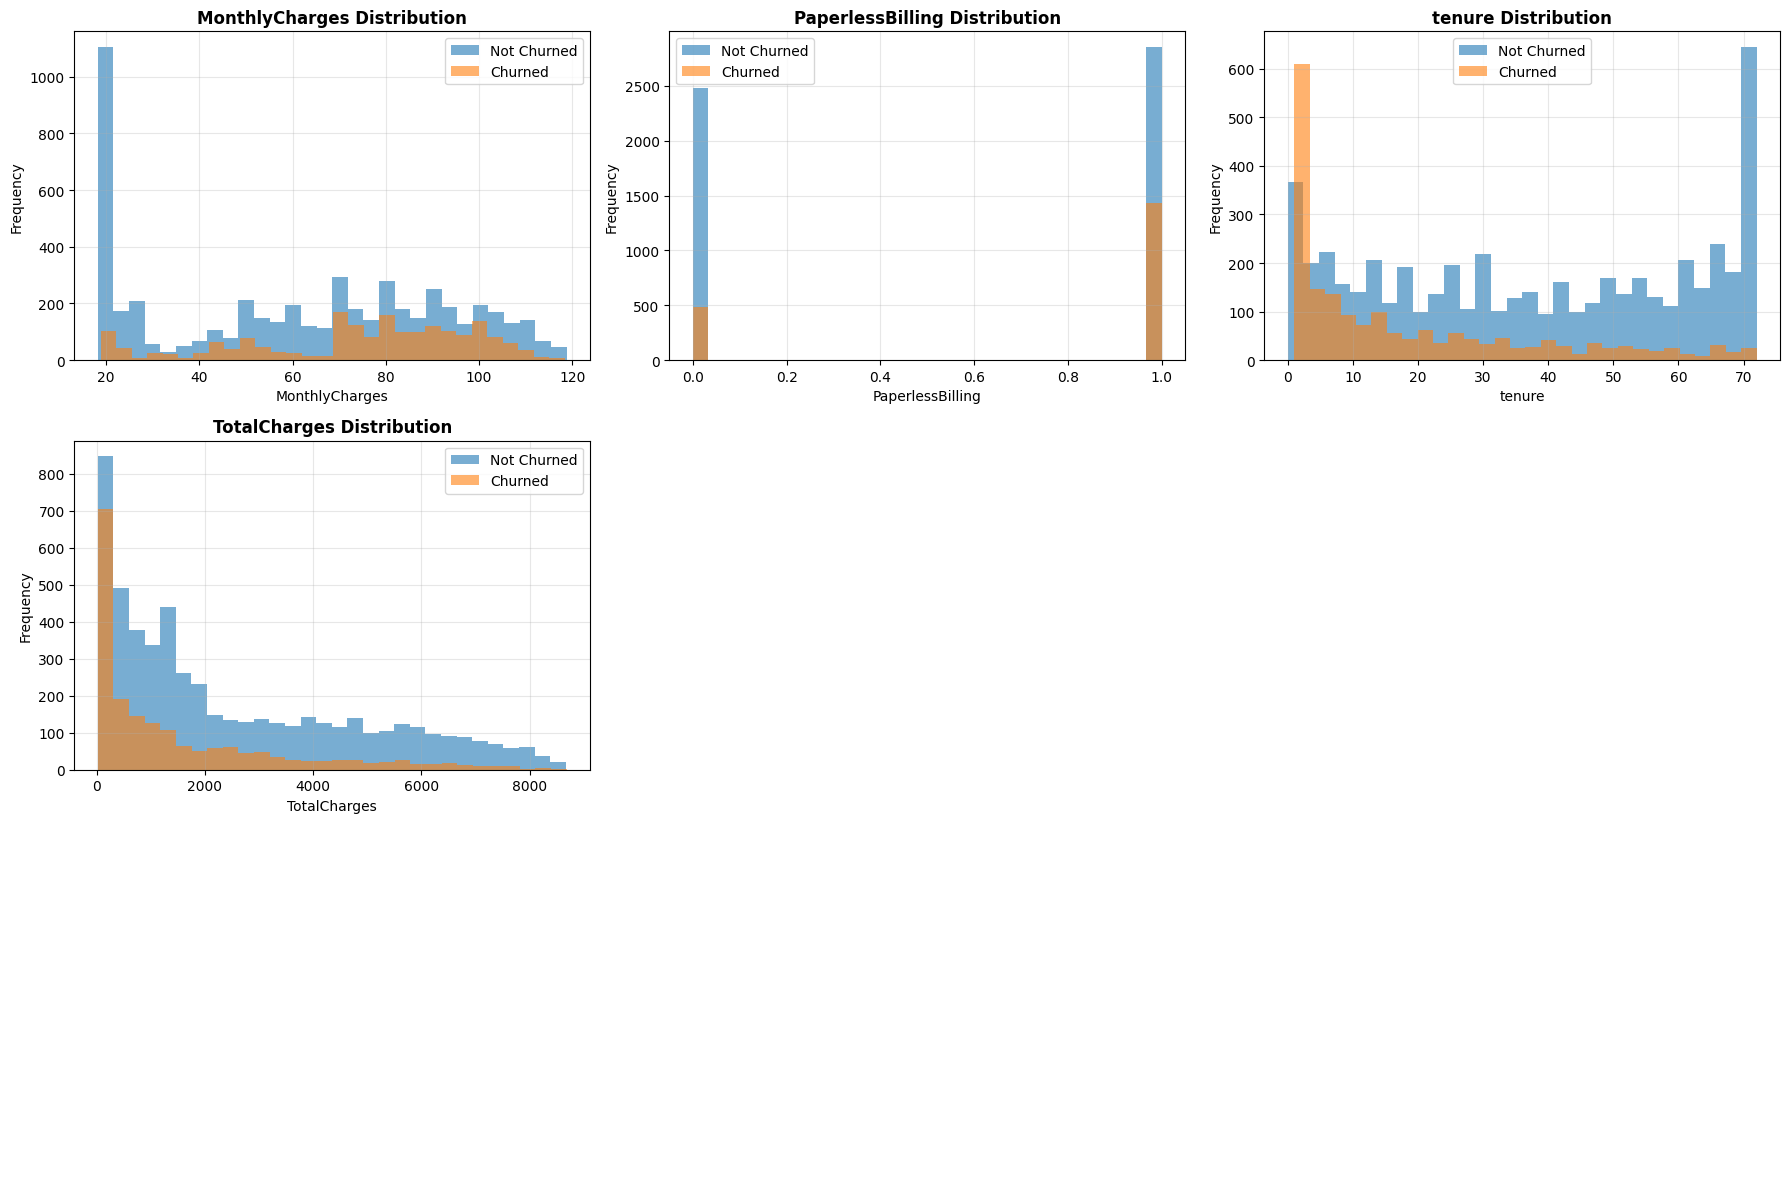

In [29]:
# Top 8 features (same as before)
top_features = [
    'InternetService_Fiber optic',
    'PaymentMethod_Electronic check',
    'MonthlyCharges',
    'PaperlessBilling',
    'tenure',
    'Contract_Two year',
    'TotalCharges',
    'Contract_One year'
]

top_features_filtered = [
    col for col in top_features
    if df_encoded[col].dtype != 'bool'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, feature in enumerate(top_features_filtered):

    df_encoded[df_encoded['Churn'] == 0][feature].hist(
        bins=30, alpha=0.6, label='Not Churned', ax=axes[idx]
    )

    df_encoded[df_encoded['Churn'] == 1][feature].hist(
        bins=30, alpha=0.6, label='Churned', ax=axes[idx]
    )

    axes[idx].set_title(f'{feature} Distribution', fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

# Hide unused subplots
for i in range(len(top_features_filtered), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

5.4 Categorical Features Analysis

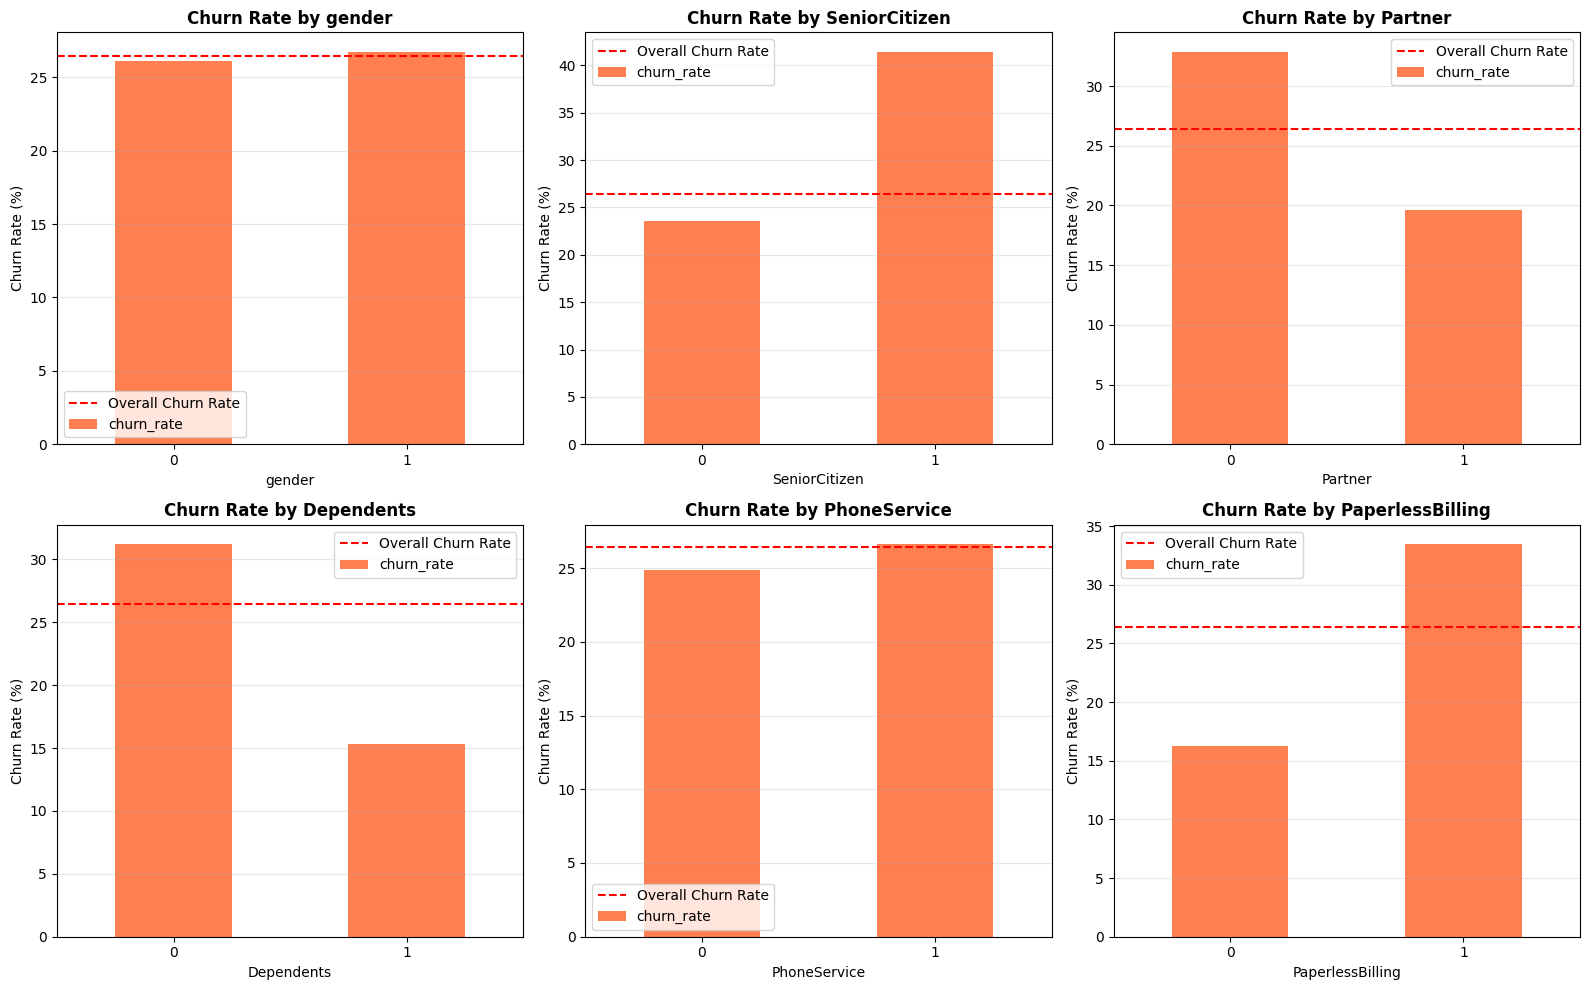

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

# Categorical features (cleaned for your dataset)
cat_features = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

overall_churn_rate = df_encoded['Churn'].mean() * 100

for idx, feature in enumerate(cat_features):

    # Group by category
    churn_by_cat = df_encoded.groupby(feature)['Churn'].agg(['sum', 'count'])
    churn_by_cat['churn_rate'] = (churn_by_cat['sum'] / churn_by_cat['count']) * 100

    # Plot
    churn_by_cat['churn_rate'].plot(
        kind='bar',
        ax=axes[idx],
        color='coral'
    )

    axes[idx].set_title(f'Churn Rate by {feature}', fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Churn Rate (%)')

    axes[idx].axhline(
        y=overall_churn_rate,
        color='red',
        linestyle='--',
        label='Overall Churn Rate'
    )

    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

5.5 Box Plots for Outlier Detection

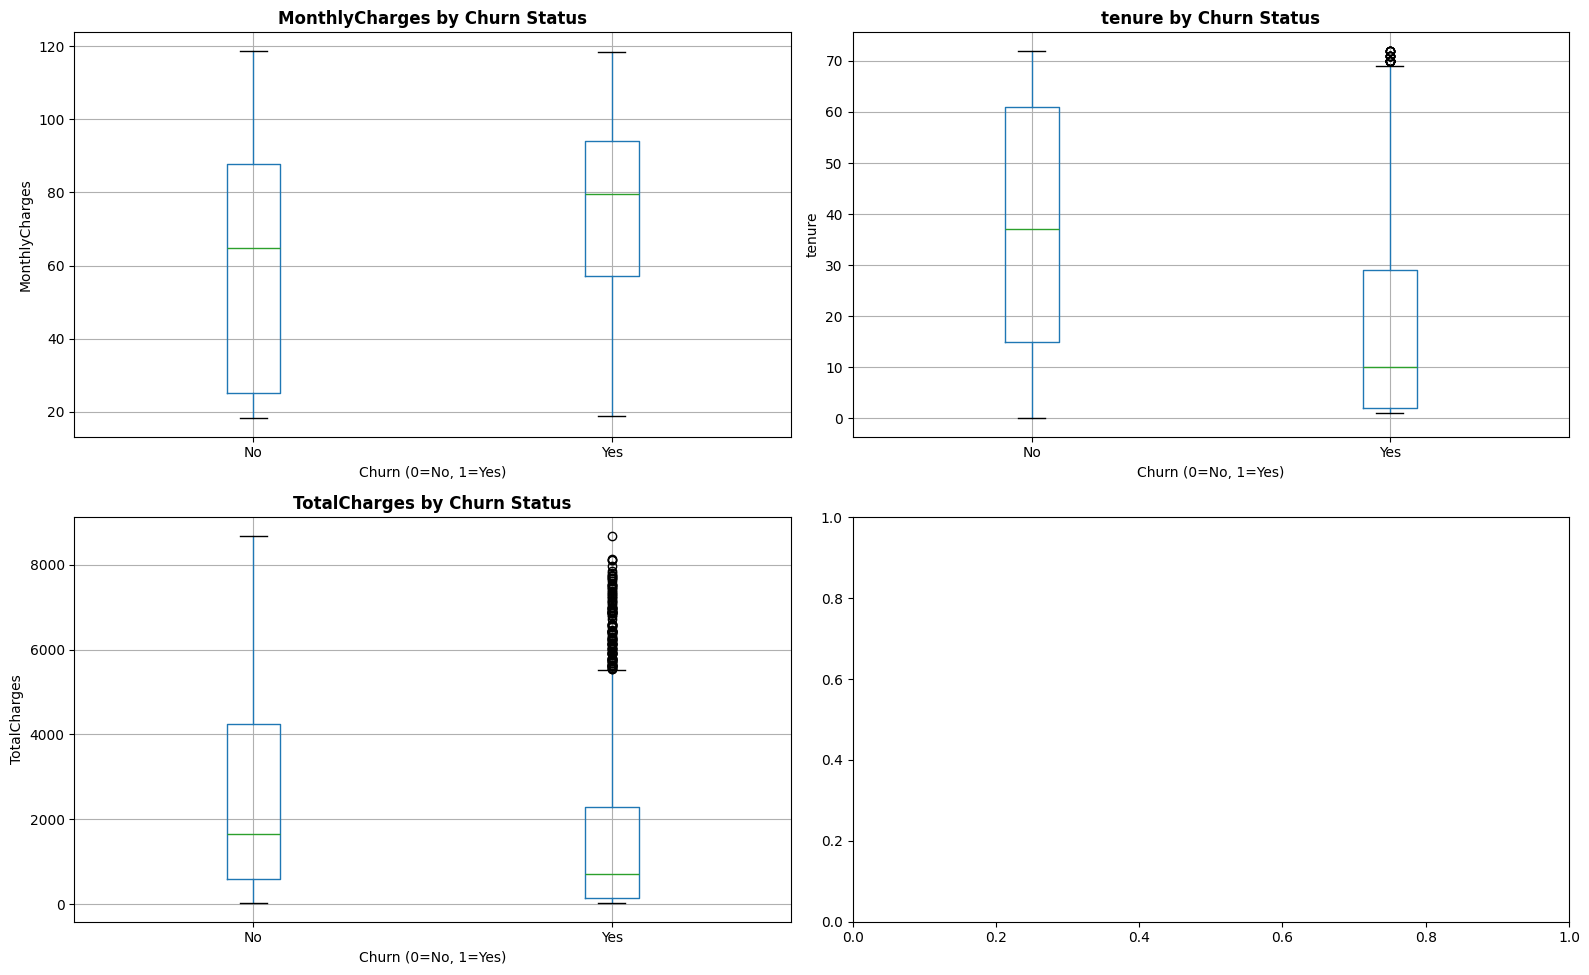

In [31]:
# Box plots for key features by churn status
key_features = [ 'MonthlyCharges',
    'tenure', 'TotalCharges']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    if feature in df_clean.columns:
        df_clean.boxplot(column=feature, by='Churn', ax=axes[idx])
        axes[idx].set_title(f'{feature} by Churn Status', fontweight='bold')
        axes[idx].set_xlabel('Churn (0=No, 1=Yes)')
        axes[idx].set_ylabel(feature)
        axes[idx].get_figure().suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

In [32]:
# Summary of EDA findings
print("="*70)
print("✓ EXPLORATORY DATA ANALYSIS COMPLETE!")
print("="*70)
print("\nKey Insights:")
print(f"1. Churn Rate: {(y.sum() / len(y) * 100):.2f}%")
print(f"2. Total Features: {X_scaled.shape[1]}")
print(f"3. Class Imbalance: {churn_counts[0]} not churned vs {churn_counts[1]} churned")
print("\nTop correlated features with churn:")
print(target_correlation[1:6])
print("\n✓ Ready for feature selection and modeling!")

✓ EXPLORATORY DATA ANALYSIS COMPLETE!

Key Insights:
1. Churn Rate: 26.43%
2. Total Features: 30
3. Class Imbalance: 5336 not churned vs 1917 churned

Top correlated features with churn:
InternetService_Fiber optic       0.308121
PaymentMethod_Electronic check    0.302440
MonthlyCharges                    0.192953
PaperlessBilling                  0.191064
SeniorCitizen                     0.149133
Name: Churn, dtype: float64

✓ Ready for feature selection and modeling!


6. Feature Selection

Here we will analyze feature importance and select most relevant features for modeling.

In [33]:
# Analyze top correlated features
top_positive = target_correlation[target_correlation > 0].sort_values(ascending=False)[1:11]
top_negative = target_correlation[target_correlation < 0].sort_values()[0:10]

print("="*70)
print("TOP 10 POSITIVE CORRELATIONS WITH CHURN:")
print("="*70)
for feature, corr in top_positive.items():
    print(f"{feature:.<40} {corr:.4f}")

print("\n" + "="*70)
print("TOP 10 NEGATIVE CORRELATIONS WITH CHURN:")
print("="*70)
for feature, corr in top_negative.items():
    print(f"{feature:.<40} {corr:.4f}")

TOP 10 POSITIVE CORRELATIONS WITH CHURN:
InternetService_Fiber optic............. 0.3081
PaymentMethod_Electronic check.......... 0.3024
MonthlyCharges.......................... 0.1930
PaperlessBilling........................ 0.1911
SeniorCitizen........................... 0.1491
StreamingTV_Yes......................... 0.0637
StreamingMovies_Yes..................... 0.0617
MultipleLines_Yes....................... 0.0397
PhoneService............................ 0.0117
gender.................................. 0.0068

TOP 10 NEGATIVE CORRELATIONS WITH CHURN:
tenure.................................. -0.3520
Contract_Two year....................... -0.2993
StreamingTV_No internet service......... -0.2283
OnlineSecurity_No internet service...... -0.2283
InternetService_No...................... -0.2283
TechSupport_No internet service......... -0.2283
OnlineBackup_No internet service........ -0.2283
DeviceProtection_No internet service.... -0.2283
StreamingMovies_No internet service..... -0.2

In [38]:
# Select features based on correlation threshold
correlation_threshold = 0.09
important_features = target_correlation[abs(target_correlation) > correlation_threshold].index.tolist()
if 'Churn' in important_features:
    important_features.remove('Churn')

print(f"Features with |correlation| > {correlation_threshold}:")
print("="*70)
print(f"Total selected features: {len(important_features)}")
print("\nSelected features:")
for i, feature in enumerate(important_features, 1):
    print(f"{i:2d}. {feature}")

Features with |correlation| > 0.09:
Total selected features: 22

Selected features:
 1. InternetService_Fiber optic
 2. PaymentMethod_Electronic check
 3. MonthlyCharges
 4. PaperlessBilling
 5. SeniorCitizen
 6. PaymentMethod_Mailed check
 7. PaymentMethod_Credit card (automatic)
 8. Partner
 9. TechSupport_Yes
10. Dependents
11. OnlineSecurity_Yes
12. Contract_One year
13. TotalCharges
14. InternetService_No
15. StreamingTV_No internet service
16. OnlineSecurity_No internet service
17. OnlineBackup_No internet service
18. DeviceProtection_No internet service
19. StreamingMovies_No internet service
20. TechSupport_No internet service
21. Contract_Two year
22. tenure


In [40]:
# For modeling, we'll use all scaled features
# (Feature selection can be refined later with model-based methods)
X_selected = X_scaled.copy()
y_selected = y.copy()

print("="*70)
print("✓ FEATURE SELECTION COMPLETE!")
print("="*70)
print(f"\nFinal feature set:")
print(f"  - Total features: {X_selected.shape[1]}")
print(f"  - Samples: {X_selected.shape[0]}")
print(f"  - Target variable: Churn")
print(f"\nNote: Using all {X_selected.shape[1]} features for comprehensive modeling")
print("Feature importance will be extracted from tree-based models later.")

✓ FEATURE SELECTION COMPLETE!

Final feature set:
  - Total features: 30
  - Samples: 7253
  - Target variable: Churn

Note: Using all 30 features for comprehensive modeling
Feature importance will be extracted from tree-based models later.


7. Data Splitting


Split the dataset into training and testing sets (80-20 split).

In [41]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_selected,
    test_size=0.2,
    random_state=42,
    stratify=y_selected
)

print("="*70)
print("✓ DATA SPLITTING COMPLETE!")
print("="*70)
print(f"\nTraining Set:")
print(f"  - X_train shape: {X_train.shape}")
print(f"  - y_train shape: {y_train.shape}")
print(f"  - Samples: {len(X_train)} ({len(X_train)/len(X_selected)*100:.1f}%)")

print(f"\nTesting Set:")
print(f"  - X_test shape: {X_test.shape}")
print(f"  - y_test shape: {y_test.shape}")
print(f"  - Samples: {len(X_test)} ({len(X_test)/len(X_selected)*100:.1f}%)")

print(f"\nChurn distribution in training set:")
print(y_train.value_counts())
print(f"Churn rate: {(y_train.sum()/len(y_train)*100):.2f}%")

print(f"\nChurn distribution in testing set:")
print(y_test.value_counts())
print(f"Churn rate: {(y_test.sum()/len(y_test)*100):.2f}%")

print(f"\n✓ Stratified split maintains class balance!")
print("Ready for model training! 🚀")

✓ DATA SPLITTING COMPLETE!

Training Set:
  - X_train shape: (5802, 30)
  - y_train shape: (5802,)
  - Samples: 5802 (80.0%)

Testing Set:
  - X_test shape: (1451, 30)
  - y_test shape: (1451,)
  - Samples: 1451 (20.0%)

Churn distribution in training set:
Churn
0    4269
1    1533
Name: count, dtype: int64
Churn rate: 26.42%

Churn distribution in testing set:
Churn
0    1067
1     384
Name: count, dtype: int64
Churn rate: 26.46%

✓ Stratified split maintains class balance!
Ready for model training! 🚀


8. Model Building - Logistic Regression


Train a Logistic Regression model to predict customer churn.

In [42]:
# Initialize Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

print("Training Logistic Regression model...")
lr_model.fit(X_train, y_train)
print("✓ Model training complete!")

# Make predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

print(f"\nPredictions generated:")
print(f"  - Predicted labels: {y_pred_lr.shape}")
print(f"  - Prediction probabilities: {y_pred_proba_lr.shape}")

Training Logistic Regression model...
✓ Model training complete!

Predictions generated:
  - Predicted labels: (1451,)
  - Prediction probabilities: (1451,)


8.1 Model Evaluation - Logistic Regression

In [43]:
# Calculate evaluation metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("="*70)
print("LOGISTIC REGRESSION - PERFORMANCE METRICS")
print("="*70)
print(f"Accuracy:  {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"Precision: {precision_lr:.4f} ({precision_lr*100:.2f}%)")
print(f"Recall:    {recall_lr:.4f} ({recall_lr*100:.2f}%)")
print(f"F1-Score:  {f1_lr:.4f} ({f1_lr*100:.2f}%)")
print("="*70)

LOGISTIC REGRESSION - PERFORMANCE METRICS
Accuracy:  0.7988 (79.88%)
Precision: 0.6456 (64.56%)
Recall:    0.5312 (53.12%)
F1-Score:  0.5829 (58.29%)


In [44]:
# Classification Report
print("\nDetailed Classification Report:")
print("="*70)
print(classification_report(y_test, y_pred_lr, target_names=['Not Churned', 'Churned']))


Detailed Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.84      0.90      0.87      1067
     Churned       0.65      0.53      0.58       384

    accuracy                           0.80      1451
   macro avg       0.74      0.71      0.73      1451
weighted avg       0.79      0.80      0.79      1451



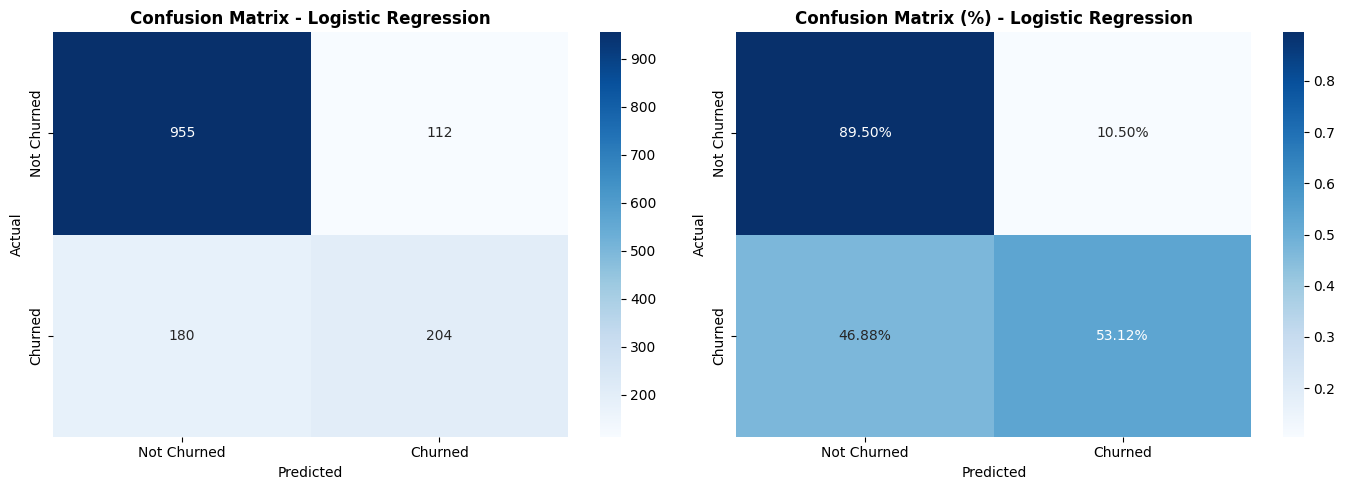

True Negatives:  955
False Positives: 112
False Negatives: 180
True Positives:  204


In [45]:
# Confusion Matrix Visualization
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix - Count
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
axes[0].set_title('Confusion Matrix - Logistic Regression', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Confusion Matrix - Percentage
cm_lr_percent = cm_lr.astype('float') / cm_lr.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_lr_percent, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
axes[1].set_title('Confusion Matrix (%) - Logistic Regression', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print(f"True Negatives:  {cm_lr[0,0]:,}")
print(f"False Positives: {cm_lr[0,1]:,}")
print(f"False Negatives: {cm_lr[1,0]:,}")
print(f"True Positives:  {cm_lr[1,1]:,}")

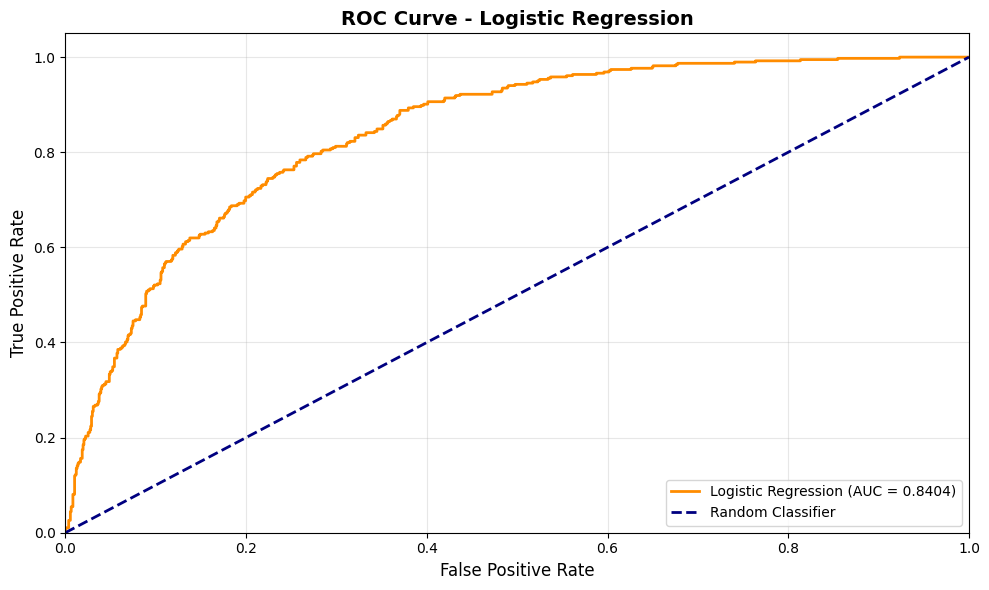

AUC Score: 0.8404


In [46]:
# ROC Curve and AUC
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2,
         label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_lr:.4f}")

In [47]:
# Save model results for comparison
model_results = {
    'Logistic Regression': {
        'accuracy': accuracy_lr,
        'precision': precision_lr,
        'recall': recall_lr,
        'f1_score': f1_lr,
        'auc': auc_lr,
        'model': lr_model
    }
}

print("="*70)
print("✓ LOGISTIC REGRESSION MODEL COMPLETE!")
print("="*70)
print(f"\nModel results saved for comparison.")
print(f"Next: Train Random Forest model...")

✓ LOGISTIC REGRESSION MODEL COMPLETE!

Model results saved for comparison.
Next: Train Random Forest model...


9. Model Building - Random Forest


Train a Random Forest classifier to predict customer churn and extract feature importance.

In [48]:
# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Training Random Forest model...")
rf_model.fit(X_train, y_train)
print("✓ Model training complete!")

# Make predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"\nPredictions generated:")
print(f"  - Predicted labels: {y_pred_rf.shape}")
print(f"  - Prediction probabilities: {y_pred_proba_rf.shape}")

Training Random Forest model...
✓ Model training complete!

Predictions generated:
  - Predicted labels: (1451,)
  - Prediction probabilities: (1451,)


In [49]:
# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("="*70)
print("RANDOM FOREST - PERFORMANCE METRICS")
print("="*70)
print(f"Accuracy:  {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
print(f"Precision: {precision_rf:.4f} ({precision_rf*100:.2f}%)")
print(f"Recall:    {recall_rf:.4f} ({recall_rf*100:.2f}%)")
print(f"F1-Score:  {f1_rf:.4f} ({f1_rf*100:.2f}%)")
print("="*70)

# Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Not Churned', 'Churned']))

RANDOM FOREST - PERFORMANCE METRICS
Accuracy:  0.7905 (79.05%)
Precision: 0.6481 (64.81%)
Recall:    0.4557 (45.57%)
F1-Score:  0.5352 (53.52%)

Detailed Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.82      0.91      0.86      1067
     Churned       0.65      0.46      0.54       384

    accuracy                           0.79      1451
   macro avg       0.74      0.68      0.70      1451
weighted avg       0.78      0.79      0.78      1451



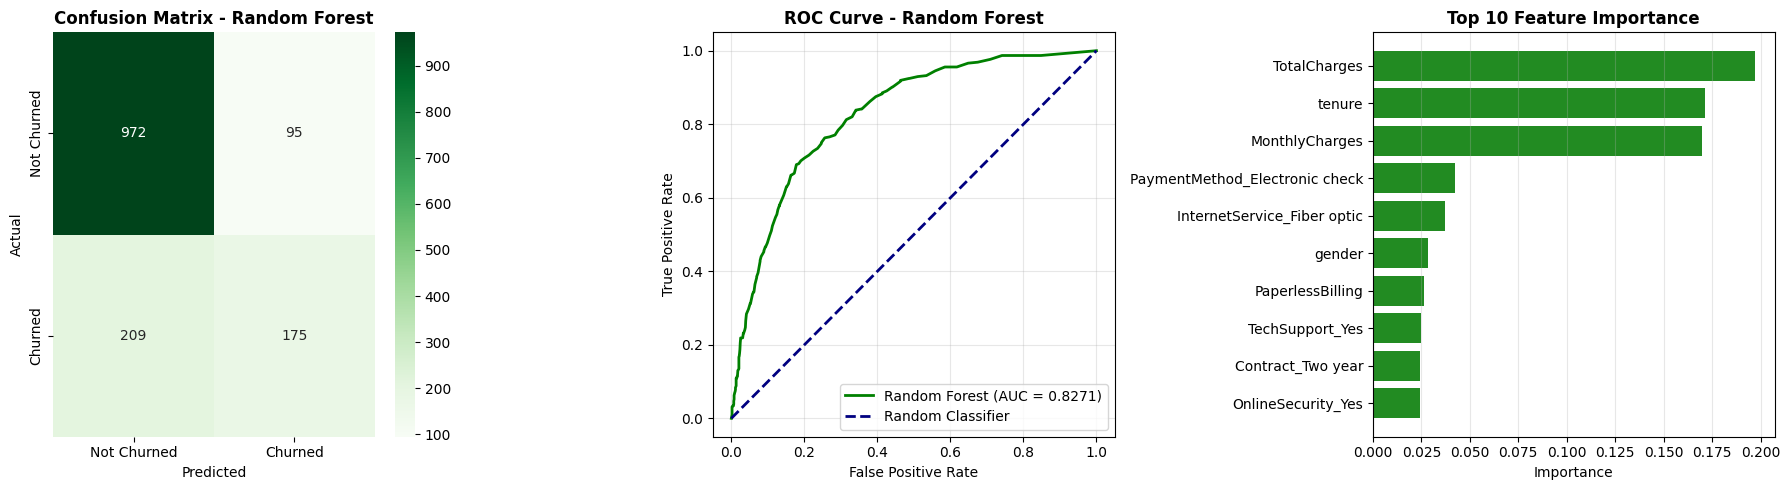


✓ Random Forest Model Complete!


In [50]:
# Confusion Matrix and ROC Curve
cm_rf = confusion_matrix(y_test, y_pred_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Not Churned', 'Churned'], yticklabels=['Not Churned', 'Churned'])
axes[0].set_title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
axes[1].plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {auc_rf:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Random Forest', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Feature Importance
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

axes[2].barh(range(len(feature_importance_rf)), feature_importance_rf['importance'], color='forestgreen')
axes[2].set_yticks(range(len(feature_importance_rf)))
axes[2].set_yticklabels(feature_importance_rf['feature'])
axes[2].set_xlabel('Importance')
axes[2].set_title('Top 10 Feature Importance', fontweight='bold')
axes[2].invert_yaxis()
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Save results
model_results['Random Forest'] = {
    'accuracy': accuracy_rf, 'precision': precision_rf, 'recall': recall_rf,
    'f1_score': f1_rf, 'auc': auc_rf, 'model': rf_model,
    'feature_importance': feature_importance_rf
}
print("\n✓ Random Forest Model Complete!")

10. Model Building - Decision Tree

In [51]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluate
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
auc_dt = auc(fpr_dt, tpr_dt)

print("DECISION TREE - PERFORMANCE METRICS")
print(f"Accuracy: {accuracy_dt:.4f} | Precision: {precision_dt:.4f} | Recall: {recall_dt:.4f} | F1: {f1_dt:.4f} | AUC: {auc_dt:.4f}")

model_results['Decision Tree'] = {
    'accuracy': accuracy_dt, 'precision': precision_dt, 'recall': recall_dt,
    'f1_score': f1_dt, 'auc': auc_dt, 'model': dt_model
}

DECISION TREE - PERFORMANCE METRICS
Accuracy: 0.7677 | Precision: 0.5761 | Recall: 0.4635 | F1: 0.5137 | AUC: 0.7346


11. Model Building - Support Vector Classifier

In [52]:
# Train SVC
svc_model = SVC(kernel='rbf', probability=True, random_state=42)
print("Training SVC model (this may take a few moments)...")
svc_model.fit(X_train, y_train)
y_pred_svc = svc_model.predict(X_test)
y_pred_proba_svc = svc_model.predict_proba(X_test)[:, 1]

# Evaluate
accuracy_svc = accuracy_score(y_test, y_pred_svc)
precision_svc = precision_score(y_test, y_pred_svc)
recall_svc = recall_score(y_test, y_pred_svc)
f1_svc = f1_score(y_test, y_pred_svc)
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_pred_proba_svc)
auc_svc = auc(fpr_svc, tpr_svc)

print("SVC - PERFORMANCE METRICS")
print(f"Accuracy: {accuracy_svc:.4f} | Precision: {precision_svc:.4f} | Recall: {recall_svc:.4f} | F1: {f1_svc:.4f} | AUC: {auc_svc:.4f}")

model_results['SVC'] = {
    'accuracy': accuracy_svc, 'precision': precision_svc, 'recall': recall_svc,
    'f1_score': f1_svc, 'auc': auc_svc, 'model': svc_model
}

Training SVC model (this may take a few moments)...
SVC - PERFORMANCE METRICS
Accuracy: 0.7974 | Precision: 0.6679 | Recall: 0.4661 | F1: 0.5491 | AUC: 0.7959


12. Model Comparison


Compare all trained models to identify the best performer.

In [53]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Accuracy': [model_results[m]['accuracy'] for m in model_results.keys()],
    'Precision': [model_results[m]['precision'] for m in model_results.keys()],
    'Recall': [model_results[m]['recall'] for m in model_results.keys()],
    'F1-Score': [model_results[m]['f1_score'] for m in model_results.keys()],
    'AUC': [model_results[m]['auc'] for m in model_results.keys()]
}).sort_values('AUC', ascending=False).reset_index(drop=True)

print("="*90)
print("MODEL COMPARISON - PERFORMANCE METRICS")
print("="*90)
print(comparison_df.to_string(index=False))
print("="*90)
print(f"\n🏆 Best Model: {comparison_df.iloc[0]['Model']} (AUC: {comparison_df.iloc[0]['AUC']:.4f})")

MODEL COMPARISON - PERFORMANCE METRICS
              Model  Accuracy  Precision   Recall  F1-Score      AUC
Logistic Regression  0.798759   0.645570 0.531250  0.582857 0.840409
      Random Forest  0.790489   0.648148 0.455729  0.535168 0.827144
                SVC  0.797381   0.667910 0.466146  0.549080 0.795933
      Decision Tree  0.767746   0.576052 0.463542  0.513709 0.734624

🏆 Best Model: Logistic Regression (AUC: 0.8404)


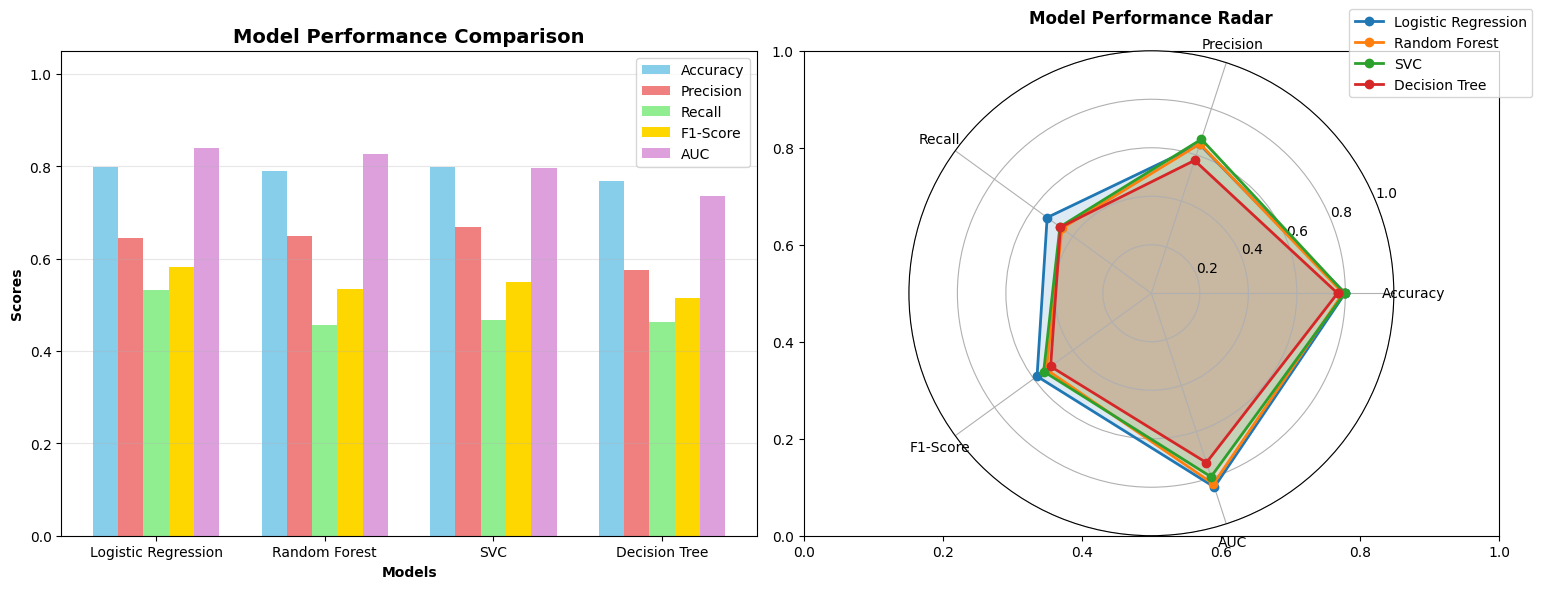

In [54]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart comparison
x = np.arange(len(comparison_df))
width = 0.15
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum']

for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width - 2*width, comparison_df[metric], width, label=metric, color=colors[i])

axes[0].set_xlabel('Models', fontweight='bold')
axes[0].set_ylabel('Scores', fontweight='bold')
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Model'])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.05])

# Radar chart
from math import pi
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

ax = plt.subplot(122, projection='polar')
colors_radar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, model_name in enumerate(comparison_df['Model']):
    values = comparison_df.iloc[idx][categories].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=colors_radar[idx])
    ax.fill(angles, values, alpha=0.15, color=colors_radar[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title('Model Performance Radar', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.show()

## 13. Model Optimization - Hyperparameter Tuning

Optimize the best performing model (Logistic Regression) using `GridSearchCV`.

In [55]:
# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

print("Starting Hyperparameter Tuning for Logistic Regression...")

# Define the parameter grid for Logistic Regression
param_grid_lr = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
}

# Instantiate GridSearchCV
grid_search_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=5, # 5-fold cross-validation
    scoring='roc_auc', # Optimize for AUC score
    n_jobs=-1, # Use all available CPU cores
    verbose=1 # Print progress
)

# Fit GridSearchCV to the training data
grid_search_lr.fit(X_train, y_train)

print("✓ Hyperparameter tuning complete!")
print(f"Best parameters found: {grid_search_lr.best_params_}")
print(f"Best cross-validation AUC score: {grid_search_lr.best_score_:.4f}")

Starting Hyperparameter Tuning for Logistic Regression...
Fitting 5 folds for each of 120 candidates, totalling 600 fits
✓ Hyperparameter tuning complete!
Best parameters found: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation AUC score: 0.8446


### Evaluate Optimized Logistic Regression Model

In [56]:
# Get the best Logistic Regression model from GridSearchCV
best_lr_model = grid_search_lr.best_estimator_

# Make predictions with the optimized model
y_pred_lr_tuned = best_lr_model.predict(X_test)
y_pred_proba_lr_tuned = best_lr_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics for the tuned model
accuracy_lr_tuned = accuracy_score(y_test, y_pred_lr_tuned)
precision_lr_tuned = precision_score(y_test, y_pred_lr_tuned)
recall_lr_tuned = recall_score(y_test, y_pred_lr_tuned)
f1_lr_tuned = f1_score(y_test, y_pred_lr_tuned)
fpr_lr_tuned, tpr_lr_tuned, _ = roc_curve(y_test, y_pred_proba_lr_tuned)
auc_lr_tuned = auc(fpr_lr_tuned, tpr_lr_tuned)

print("="*70)
print("OPTIMIZED LOGISTIC REGRESSION - PERFORMANCE METRICS")
print("="*70)
print(f"Accuracy:  {accuracy_lr_tuned:.4f} ({accuracy_lr_tuned*100:.2f}%)")
print(f"Precision: {precision_lr_tuned:.4f} ({precision_lr_tuned*100:.2f}%)")
print(f"Recall:    {recall_lr_tuned:.4f} ({recall_lr_tuned*100:.2f}%)")
print(f"F1-Score:  {f1_lr_tuned:.4f} ({f1_lr_tuned*100:.2f}%)")
print(f"AUC:       {auc_lr_tuned:.4f}")
print("="*70)

# Update model results with the tuned LR model
model_results['Optimized Logistic Regression'] = {
    'accuracy': accuracy_lr_tuned,
    'precision': precision_lr_tuned,
    'recall': recall_lr_tuned,
    'f1_score': f1_lr_tuned,
    'auc': auc_lr_tuned,
    'model': best_lr_model
}

# Classification Report
print("\nDetailed Classification Report (Optimized LR):")
print("="*70)
print(classification_report(y_test, y_pred_lr_tuned, target_names=['Not Churned', 'Churned']))

OPTIMIZED LOGISTIC REGRESSION - PERFORMANCE METRICS
Accuracy:  0.8008 (80.08%)
Precision: 0.6498 (64.98%)
Recall:    0.5365 (53.65%)
F1-Score:  0.5877 (58.77%)
AUC:       0.8410

Detailed Classification Report (Optimized LR):
              precision    recall  f1-score   support

 Not Churned       0.84      0.90      0.87      1067
     Churned       0.65      0.54      0.59       384

    accuracy                           0.80      1451
   macro avg       0.75      0.72      0.73      1451
weighted avg       0.79      0.80      0.79      1451



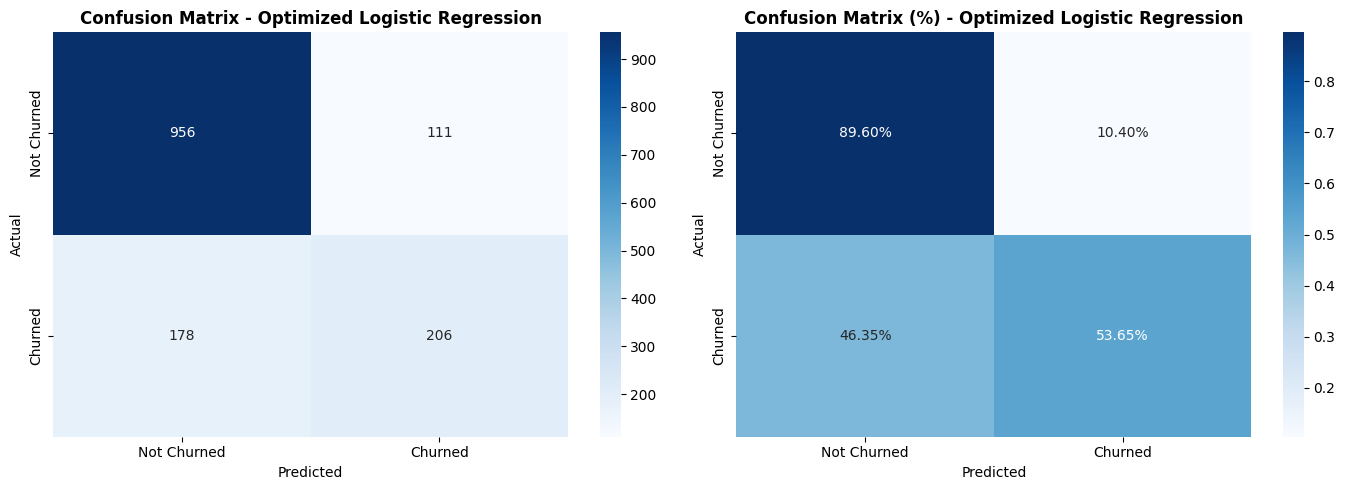

In [57]:
# Confusion Matrix Visualization (Optimized LR)
cm_lr_tuned = confusion_matrix(y_test, y_pred_lr_tuned)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix - Count
sns.heatmap(cm_lr_tuned, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
axes[0].set_title('Confusion Matrix - Optimized Logistic Regression', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Confusion Matrix - Percentage
cm_lr_tuned_percent = cm_lr_tuned.astype('float') / cm_lr_tuned.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_lr_tuned_percent, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
axes[1].set_title('Confusion Matrix (%) - Optimized Logistic Regression', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

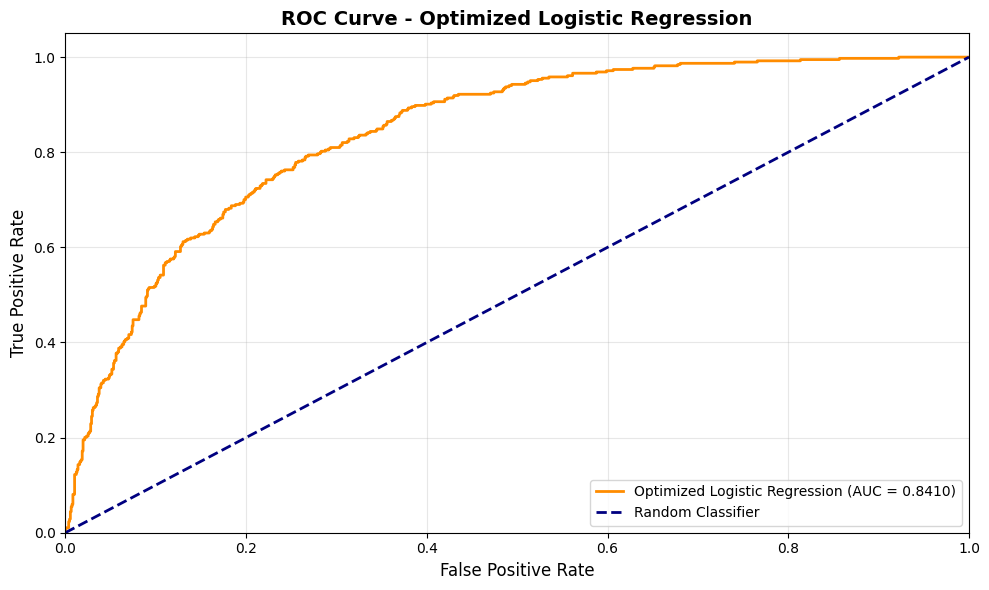

AUC Score (Optimized LR): 0.8410


In [58]:
# ROC Curve and AUC (Optimized LR)
plt.figure(figsize=(10, 6))
plt.plot(fpr_lr_tuned, tpr_lr_tuned, color='darkorange', lw=2,
         label=f'Optimized Logistic Regression (AUC = {auc_lr_tuned:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Optimized Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score (Optimized LR): {auc_lr_tuned:.4f}")

## 14. Re-compare Models

Let's re-compare all models, including the newly optimized Logistic Regression.

UPDATED MODEL COMPARISON - PERFORMANCE METRICS
                        Model  Accuracy  Precision   Recall  F1-Score      AUC
Optimized Logistic Regression  0.800827   0.649842 0.536458  0.587732 0.840980
          Logistic Regression  0.798759   0.645570 0.531250  0.582857 0.840409
                Random Forest  0.790489   0.648148 0.455729  0.535168 0.827144
                          SVC  0.797381   0.667910 0.466146  0.549080 0.795933
                Decision Tree  0.767746   0.576052 0.463542  0.513709 0.734624

🏆 Best Model: Optimized Logistic Regression (AUC: 0.8410)


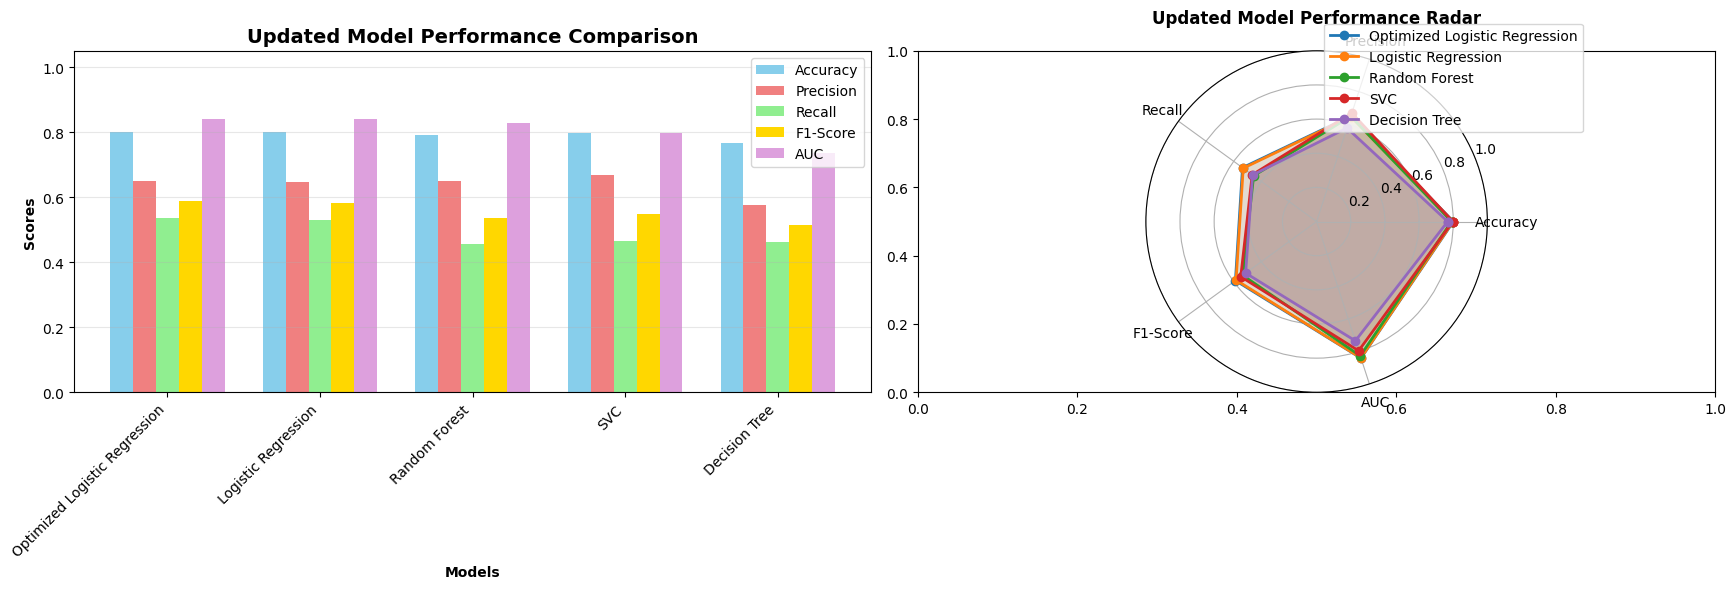

In [59]:
# Create updated comparison DataFrame
updated_comparison_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Accuracy': [model_results[m]['accuracy'] for m in model_results.keys()],
    'Precision': [model_results[m]['precision'] for m in model_results.keys()],
    'Recall': [model_results[m]['recall'] for m in model_results.keys()],
    'F1-Score': [model_results[m]['f1_score'] for m in model_results.keys()],
    'AUC': [model_results[m]['auc'] for m in model_results.keys()]
}).sort_values('AUC', ascending=False).reset_index(drop=True)

print("="*90)
print("UPDATED MODEL COMPARISON - PERFORMANCE METRICS")
print("="*90)
print(updated_comparison_df.to_string(index=False))
print("="*90)
print(f"\n🏆 Best Model: {updated_comparison_df.iloc[0]['Model']} (AUC: {updated_comparison_df.iloc[0]['AUC']:.4f})")

# Visualize updated model comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart comparison
x_updated = np.arange(len(updated_comparison_df))
width = 0.15
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum']

for i, metric in enumerate(metrics):
    axes[0].bar(x_updated + i*width - 2*width, updated_comparison_df[metric], width, label=metric, color=colors[i])

axes[0].set_xlabel('Models', fontweight='bold')
axes[0].set_ylabel('Scores', fontweight='bold')
axes[0].set_title('Updated Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_updated)
axes[0].set_xticklabels(updated_comparison_df['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.05])

# Radar chart
from math import pi
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
N_updated = len(categories)
angles_updated = [n / float(N_updated) * 2 * pi for n in range(N_updated)]
angles_updated += angles_updated[:1]

ax_radar_updated = plt.subplot(122, projection='polar')
colors_radar_updated = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] # Added a new color for the optimized model

for idx, model_name in enumerate(updated_comparison_df['Model']):
    values_updated = updated_comparison_df.iloc[idx][categories].values.tolist()
    values_updated += values_updated[:1]
    ax_radar_updated.plot(angles_updated, values_updated, 'o-', linewidth=2, label=model_name, color=colors_radar_updated[idx])
    ax_radar_updated.fill(angles_updated, values_updated, alpha=0.15, color=colors_radar_updated[idx])

ax_radar_updated.set_xticks(angles_updated[:-1])
ax_radar_updated.set_xticklabels(categories)
ax_radar_updated.set_ylim(0, 1)
ax_radar_updated.set_title('Updated Model Performance Radar', fontweight='bold', pad=20)
ax_radar_updated.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax_radar_updated.grid(True)

plt.tight_layout()
plt.show()